In [96]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans

In [97]:
df = pd.read_csv("C:/Users/Eduardo Filho/Desktop/projeto ICD/Trabalho-ICD-/CSVs/Dados unidos/dados_mensais_unificado.csv")

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17382 entries, 0 to 17381
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Categoria                17382 non-null  str  
 1   Especificação            17301 non-null  str  
 2   Porcentagens             17382 non-null  str  
 3   Incrementos/Decrementos  17382 non-null  str  
 4   Mês                      17382 non-null  str  
 5   Ano                      17382 non-null  int64
dtypes: int64(1), str(5)
memory usage: 814.9 KB


In [98]:
df.head(5)

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano
0,OS Version,Windows,95.92%,+0.06%,Janeiro,2019
1,OS Version,Windows 10 64 bit,63.77%,-0.02%,Janeiro,2019
2,OS Version,Windows 7 64 bit,26.40%,+0.32%,Janeiro,2019
3,OS Version,Windows 8.1 64 bit,3.43%,-0.10%,Janeiro,2019
4,OS Version,Windows 7,1.52%,-0.09%,Janeiro,2019


### Valores nulos da coluna Espacificação.

Os valores nulos da coluna especificação possui a característica de ser todos pertencentes a categoria Video Card Description, alguns desses valores possuem uma porcentagem significativa outros nem tanto. Porém, ao procurar a fonte dos dados é possível identificar que é um erro da própria base de dados. Há duas opções: fazer a procura desses dados manualmente para substituir ou apagar as linnhas.

In [99]:
print(df[df["Especificação"].isnull()])

                    Categoria Especificação Porcentagens  \
140    Video Card Description           NaN        0.24%   
334    Video Card Description           NaN        0.23%   
523    Video Card Description           NaN        0.25%   
713    Video Card Description           NaN        0.25%   
902    Video Card Description           NaN        0.27%   
...                       ...           ...          ...   
15977  Video Card Description           NaN        1.77%   
16193  Video Card Description           NaN        1.93%   
16408  Video Card Description           NaN        1.78%   
16628  Video Card Description           NaN        1.05%   
16803  Video Card Description           NaN        2.13%   

      Incrementos/Decrementos        Mês   Ano  
140                    +0.01%    Janeiro  2019  
334                    -0.01%  Fevereiro  2019  
523                    +0.02%      Março  2019  
713                     0.00%      Abril  2019  
902                    +0.02%     

In [100]:
df["Porcentagens"] = df["Porcentagens"].str.replace("%", "")
df["Porcentagens"] = df["Porcentagens"].astype(float)



In [101]:
df["Incrementos/Decrementos"] = df["Incrementos/Decrementos"].str.replace("%","")
df["Incrementos/Decrementos"] = df["Incrementos/Decrementos"].str.replace("+","")
df["Incrementos/Decrementos"] = df["Incrementos/Decrementos"].astype(float)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17382 entries, 0 to 17381
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Categoria                17382 non-null  str    
 1   Especificação            17301 non-null  str    
 2   Porcentagens             17382 non-null  float64
 3   Incrementos/Decrementos  17382 non-null  float64
 4   Mês                      17382 non-null  str    
 5   Ano                      17382 non-null  int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 814.9 KB


In [102]:
a = df[df["Especificação"].isnull()]
print(f'Linhas faltantes: {len(a)}')
for i in range(len(a)):
    print(f" Categoria: {a["Categoria"].iloc[i]} Porcentagem: {a['Porcentagens'].iloc[i]}, mês: {a['Mês'].iloc[i]}, ano: {a['Ano'].iloc[i]}")

Linhas faltantes: 81
 Categoria: Video Card Description Porcentagem: 0.24, mês: Janeiro, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.23, mês: Fevereiro, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.25, mês: Março, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.25, mês: Abril, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.27, mês: Maio, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.25, mês: Junho, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.26, mês: Julho, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.31, mês: Agosto, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.34, mês: Setembro, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.24, mês: Outubro, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.2, mês: Novembro, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.16, mês: Dezembro, ano: 2019
 Categoria: Video Card Description Porcentagem: 0.2

### Ideia para resolução dos valores nulos. 

Ao analisar os dados: a porcentagem final de usuários de uma determinada categoria depende do seu valor no mês anterior e o seu incremento para aquele mês. A ideia é fazer o caminho inverso para tentar encontrar esse componente: Encontrar um valor que subtraído o incremento daquele mês possa encontrar um compomente do mês anterior e substituir o valor nulo por ele. 

In [103]:
disc = {"Janeiro" : 0,
       "Fevereiro" : 1,
       "Março" : 2,
       "Abril" : 3,
       "Maio" : 4,
       "Junho" : 5,
       "Julho" : 6,
       "Agosto" : 7,
       "Setembro" : 8,
       "Outubro" : 9,
       "Novembro" : 10,
       "Dezembro" : 11,
       }

### Substituição dos valores com base no Mês anterior.

Esse código possui alguns desafios: O mesmo hardware não possui nome em meses consecutivos, então muitas vezes um mês anterior não resolve. Além disso em alguns casos vários hardwares seriam possíveis para substituir o mesmo dado faltante com base nos cálculos ou não podiam ser preenchido por causa da falta de dados de 2018 para trás.

In [104]:
mascara_video = df["Categoria"] == "Video Card Description"
total_nulos_inicial = df.loc[mascara_video, "Especificação"].isnull().sum()

for i in range(20):
    video = df[mascara_video].copy()
    video["chave"] = video["Ano"] * 12 + video["Mês"].map(disc)

    nulos = video[video["Especificação"].isnull()]
    if nulos.empty:
        break

    preenchidos = 0
    for idx, linha in nulos.iterrows():
        valor_alvo = linha["Porcentagens"] - linha["Incrementos/Decrementos"]
        chave_anterior = linha["chave"] - 1

        candidatos = video[
            (video["chave"] == chave_anterior)
            & np.isclose(video["Porcentagens"], valor_alvo, atol=0.005)
            & video["Especificação"].notnull()
        ]
        especificacoes = candidatos["Especificação"].unique()

        if len(especificacoes) == 1:
            df.loc[idx, "Especificação"] = especificacoes[0]
            preenchidos += 1

    if preenchidos == 0:
        break

total_nulos_final = df.loc[mascara_video, "Especificação"].isnull().sum()
print(f"Nulos preenchidos: {total_nulos_inicial - total_nulos_final} de {total_nulos_inicial}")

Nulos preenchidos: 35 de 81


In [105]:
restantes = df[mascara_video & df["Especificação"].isnull()]
print(f"Linhas ainda nulas: {len(restantes)}")
restantes[["Categoria", "Porcentagens", "Incrementos/Decrementos", "Mês", "Ano"]]

Linhas ainda nulas: 46


,Categoria,Porcentagens,Incrementos/Decrementos,Mês,Ano
140,Video Card Description,0.24,0.01,Janeiro,2019
334,Video Card Description,0.23,-0.01,Fevereiro,2019
713,Video Card Description,0.25,0.00,Abril,2019
902,Video Card Description,0.27,0.02,Maio,2019
1092,Video Card Description,0.25,-0.02,Junho,2019
1851,Video Card Description,0.24,0.01,Outubro,2019
2054,Video Card Description,0.20,-0.04,Novembro,2019
2247,Video Card Description,0.16,-0.04,Dezembro,2019
2426,Video Card Description,0.20,0.01,Janeiro,2020
2629,Video Card Description,0.19,-0.01,Fevereiro,2020


### Remoção das linhas nulas restantes

In [106]:
df = df.drop(restantes.index).reset_index(drop=True)
print(f"Linhas removidas: {len(restantes)}")
print(f"Nulos restantes em Especificação: {df['Especificação'].isnull().sum()}")

Linhas removidas: 46
Nulos restantes em Especificação: 0


In [107]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17336 entries, 0 to 17335
Data columns (total 6 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Categoria                17336 non-null  str    
 1   Especificação            17336 non-null  str    
 2   Porcentagens             17336 non-null  float64
 3   Incrementos/Decrementos  17336 non-null  float64
 4   Mês                      17336 non-null  str    
 5   Ano                      17336 non-null  int64  
dtypes: float64(2), int64(1), str(3)
memory usage: 812.8 KB


In [108]:
ORDEM_MESES = {
    "Janeiro": 1, "Fevereiro": 2, "Março": 3, "Abril": 4,
    "Maio": 5, "Junho": 6, "Julho": 7, "Agosto": 8,
    "Setembro": 9, "Outubro": 10, "Novembro": 11, "Dezembro": 12,
}

In [109]:
df_2019 = df[df['Ano'] == 2019].reset_index(drop=True)
df_2020 = df[df['Ano'] == 2020].reset_index(drop=True)
df_2021 = df[df['Ano'] == 2021].reset_index(drop=True)
df_2022 = df[df['Ano'] == 2022].reset_index(drop=True)
df_2023 = df[df['Ano'] == 2023].reset_index(drop=True)
df_2024 = df[df['Ano'] == 2024].reset_index(drop=True)
df_2025 = df[df['Ano'] == 2025].reset_index(drop=True)
df_2026 = df[df['Ano'] == 2026].reset_index(drop=True)








In [110]:
dezembro_2019 = (
    df[(df['Mês'] == 'Dezembro') & (df['Ano'] == 2019)]
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2020 = (
    df[(df['Mês'] == 'Dezembro') & (df['Ano'] == 2020)]
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2021 = (
    df[(df['Mês'] == 'Dezembro') & (df['Ano'] == 2021)]
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2022 = (
    df[(df['Mês'] == 'Dezembro') & (df['Ano'] == 2022)]
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2023 = (
   df[(df['Mês'] == 'Dezembro') & (df['Ano'] == 2023)]
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2024 = (
    df[(df['Mês'] == 'Dezembro') & (df['Ano'] == 2024)]
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

dezembro_2025 = (
    df[(df['Mês'] == 'Dezembro') & (df['Ano'] == 2025)]
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

maio_2026 = (
    df[(df['Mês'] == 'Maio') & (df['Ano'] == 2026)]
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens']]
    .copy()
)

In [111]:
maio_2026.head()

,Ano,Categoria,Especificação,Porcentagens
17108,2026,OS Version,Windows,93.85
17109,2026,OS Version,Windows 11 64 bit,69.76
17110,2026,OS Version,Windows 10 64 bit,23.99
17111,2026,OS Version,Windows 7 64 bit,0.07
17112,2026,OS Version,OSX,2.16


In [112]:
primeira_2019 = (df_2019.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2020 = (df_2020.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2021 = (df_2021.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)
primeira_2022 = (df_2022.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2023 = (df_2023.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2024 = (df_2024.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2025 = (df_2025.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

primeira_2026 = (df_2026.groupby(['Ano', 'Categoria', 'Especificação'], as_index=False).first()
    [['Ano', 'Categoria', 'Especificação', 'Porcentagens', 'Mês']]
    .rename(columns={'Porcentagens': 'Porcentagem_Inicial','Mês': 'Primeiro_Mês'})
)

In [113]:
resultado_2019 = pd.merge(dezembro_2019,primeira_2019,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2019['Incrementos/Decrementos'] = (resultado_2019['Porcentagens'] - resultado_2019['Porcentagem_Inicial']).round(2)

resultado_2020 = pd.merge(dezembro_2020,primeira_2020,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2020['Incrementos/Decrementos'] = (resultado_2020['Porcentagens'] - resultado_2020['Porcentagem_Inicial']).round(2)

resultado_2021 = pd.merge(dezembro_2021,primeira_2021,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2021['Incrementos/Decrementos'] = (resultado_2021['Porcentagens'] - resultado_2021['Porcentagem_Inicial']).round(2)

resultado_2022 = pd.merge(dezembro_2022,primeira_2022,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2022['Incrementos/Decrementos'] = (resultado_2022['Porcentagens'] - resultado_2022['Porcentagem_Inicial']).round(2)

resultado_2023 = pd.merge(dezembro_2023,primeira_2023,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2023['Incrementos/Decrementos'] = (resultado_2023['Porcentagens'] - resultado_2023['Porcentagem_Inicial']).round(2)

resultado_2024 = pd.merge(dezembro_2024,primeira_2024,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2024['Incrementos/Decrementos'] = (resultado_2024['Porcentagens'] - resultado_2024['Porcentagem_Inicial']).round(2)

resultado_2025 = pd.merge(dezembro_2025,primeira_2025,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2025['Incrementos/Decrementos'] = (resultado_2025['Porcentagens'] - resultado_2025['Porcentagem_Inicial']).round(2)

resultado_2026 = pd.merge(maio_2026,primeira_2026,on=['Ano', 'Categoria', 'Especificação'],how='inner')
resultado_2026['Incrementos/Decrementos'] = (resultado_2026['Porcentagens'] - resultado_2026['Porcentagem_Inicial']).round(2)

In [114]:
resultados = [resultado_2019, resultado_2020, resultado_2021, resultado_2022, resultado_2023, resultado_2024, resultado_2025, resultado_2026]
csv_final = pd.DataFrame()
colunas = ['Categoria', 'Especificação', 'Porcentagens', 'Incrementos/Decrementos', 'Ano']

csv_final = pd.concat([r[colunas] for r in resultados], ignore_index=True)


In [115]:
csv_final.info()

<class 'pandas.DataFrame'>
RangeIndex: 1606 entries, 0 to 1605
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Categoria                1606 non-null   str    
 1   Especificação            1606 non-null   str    
 2   Porcentagens             1606 non-null   float64
 3   Incrementos/Decrementos  1606 non-null   float64
 4   Ano                      1606 non-null   int64  
dtypes: float64(2), int64(1), str(2)
memory usage: 62.9 KB


In [116]:
ARQUIVO_SAIDA = 'dados_anuais_novo.csv'
csv_final.to_csv(ARQUIVO_SAIDA, index=False)

## Análise de dados
Para a análise decidimos fazer cópias dos datasets limpos para cada análise já que cada análise precisará manipulações distintas dos dados.

In [117]:
df_memoria = df[df['Categoria'] == 'System RAM'].reset_index(drop=True)
chave = df_memoria["Ano"] * 12 + df_memoria["Mês"].map(ORDEM_MESES)
inicio = 2025 * 12 + ORDEM_MESES["Setembro"]
fim = chave.max()

df_memoria = df_memoria[(chave >= inicio) & (chave <= fim)].copy().reset_index(drop=True)
df_memoria.head()

,Categoria,Especificação,Porcentagens,Incrementos/Decrementos,Mês,Ano
0,System RAM,Less than 4 GB,0.02,0.00,Setembro,2025
1,System RAM,4 GB,1.55,-0.03,Setembro,2025
2,System RAM,8 GB,8.05,-0.06,Setembro,2025
3,System RAM,12 GB,2.57,0.02,Setembro,2025
4,System RAM,16 GB,41.76,-0.12,Setembro,2025


In [118]:
df_memoria['Especificação'].unique()

<StringArray>
[ 'Less than 4 GB',            '4 GB',            '8 GB',           '12 GB',
           '16 GB',           '24 GB',           '28 GB',           '32 GB',
           '48 GB',           '60 GB',           '64 GB', 'More than 64 GB',
           'Other']
Length: 13, dtype: str

In [123]:
tiers_ordem = ['-4','4', '8','12','16','24','28','32','48','60','64', '64+', 'Outro (não classificado)']

# "Tabela de tradução": cada texto original vira uma faixa de RAM.
# Textos que não aparecem aqui (ex: '2 GB', 'Less than 2 GB') viram NaN.
mapa_tier = {
    'Less than 4 GB' : '-4',
    '4 GB': '4',
    '8 GB': '8',
    '12 GB' : '12',
    '16 GB': '16',
    '24 GB' : '24',
    '28 GB' : '28',
    '32 GB': '32',
    '48 GB' : '48',
    '60 GB' : '60', 
    '64 GB': '64',
    'More than 64 GB': '64+',
    'Other': 'Outro (não classificado)',
}

df_tiers = df_memoria[df_memoria['Categoria'] == 'System RAM'].copy()
df_tiers['Tier'] = df_tiers['Especificação'].map(mapa_tier)
df_tiers = df_tiers.dropna(subset=['Tier'])

# Agrupamento: soma a porcentagem de cada faixa de RAM, por ano
tier_pct = df_tiers.groupby(['Ano', 'Tier', 'Mês'])['Porcentagens'].sum().reset_index()
tier_pct.head()

,Ano,Tier,Mês,Porcentagens
0,2025,-4,Dezembro,0.02
1,2025,-4,Novembro,0.02
2,2025,-4,Outubro,0.02
3,2025,-4,Setembro,0.02
4,2025,12,Dezembro,2.63


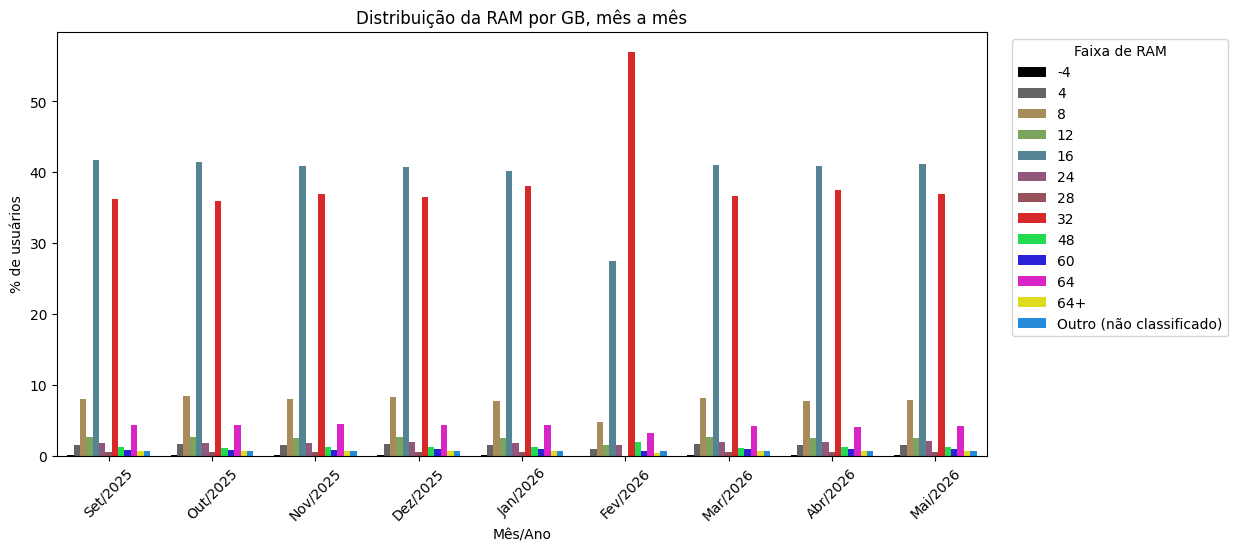

In [ ]:
tier_pct['Periodo'] = tier_pct['Mês'].str.slice(0, 3) + '/' + tier_pct['Ano'].astype(str)
ordem_periodo = (
    tier_pct[['Ano', 'Mês', 'Periodo']]
    .drop_duplicates()
    .assign(chave=lambda d: d['Ano'] * 12 + d['Mês'].map(ORDEM_MESES))
    .sort_values('chave')['Periodo']
    .tolist()
)

cores = {
    '-4' : '#000000',
        '4': "#666363",
        '8': "#B48E4D",
        '12' : "#7CB052",
        '16': "#4A8A9C",
        '24' : "#994F7D",
        '28' : "#A14652",
        '32': "#F40C0C",
        '48' : "#05F942",
        '60' : "#1105F7", 
        '64': "#F706DE",
        '64+':"#FEFA01",
        'Outro (não classificado)': "#068EF7",
}

plt.figure(figsize=(12, 5.5))

ax = sns.barplot(
    data=tier_pct,
    x='Periodo',
    order=ordem_periodo,
    y='Porcentagens',
    hue='Tier',
    hue_order=tiers_ordem,
    palette=cores
)

plt.title('Distribuição da RAM por GB, mês a mês')
plt.xlabel('Mês/Ano')
plt.ylabel('% de usuários')
plt.xticks(rotation=45)
plt.legend(title='Faixa de RAM', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.show()